# Trigonometric Fourier series

For a periodic signal $x(t)$ with period $T$ and fundamental angular frequency

$$\omega_0 = \frac{2\pi}{T},$$

the trigonometric Fourier series reads

$$x(t) = a_0 + \sum_{n=1}^{\infty} a_n \cos(n\omega_0 t) + b_n \sin(n\omega_0 t) \qquad \dots (1)$$

where

$$a_0 = \frac{1}{T}\int_{t_0}^{t_0+T} x(t)\,dt,$$

$$a_n = \frac{2}{T}\int_{t_0}^{t_0+T} x(t)\cos(n\omega_0 t)\,dt,$$

$$b_n = \frac{2}{T}\int_{t_0}^{t_0+T} x(t)\sin(n\omega_0 t)\,dt.$$

In equation (1), by multiplying the numerator and denominator of the sine and cosine terms with $\left(\sqrt{a_n^2 + b_n^2}\right)$, we get

$$x(t) = a_0 + \sum_{n=1}^{\infty}\left(\sqrt{a_n^2 + b_n^2}\right)\left(\frac{a_n}{\sqrt{a_n^2 + b_n^2}}\cos(n\omega_0 t) + \frac{b_n}{\sqrt{a_n^2 + b_n^2}}\sin(n\omega_0 t)\right) \qquad \dots (2)$$

Putting the values in the equation (2) as,

$$a_0 = A_0$$

$$\sqrt{a_n^2 + b_n^2} = A_n \qquad \dots (3)$$

$$\frac{a_n}{\sqrt{a_n^2 + b_n^2}} = \cos\theta_n \quad\text{and}\quad \frac{b_n}{\sqrt{a_n^2 + b_n^2}} = -\sin\theta_n$$

We obtain,

$$x(t) = A_0 + \sum_{n=1}^{\infty} A_n\left(\cos\theta_n \cos(n\omega_0 t) - \sin\theta_n \sin(n\omega_0 t)\right)$$

$$\Rightarrow x(t) = A_0 + \sum_{n=1}^{\infty} A_n \cos(n\omega_0 t + \theta_n) \qquad \dots (4)$$

Where,

$$\theta_n = -\tan^{-1}\left(\frac{b_n}{a_n}\right) \qquad \dots (5)$$

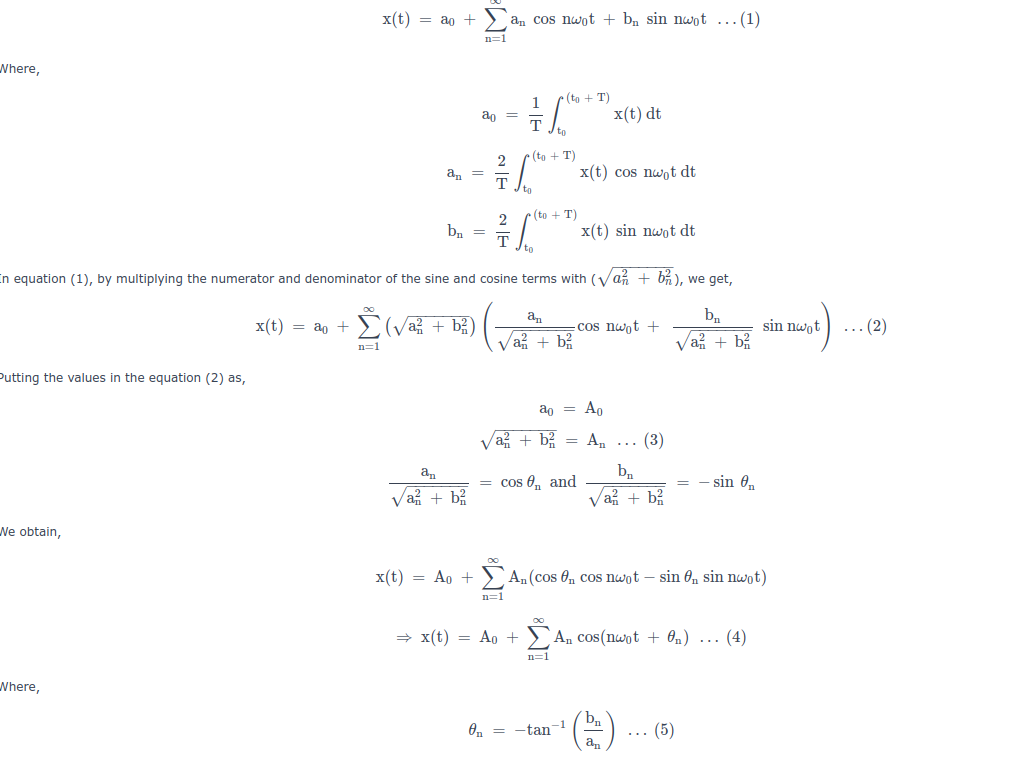
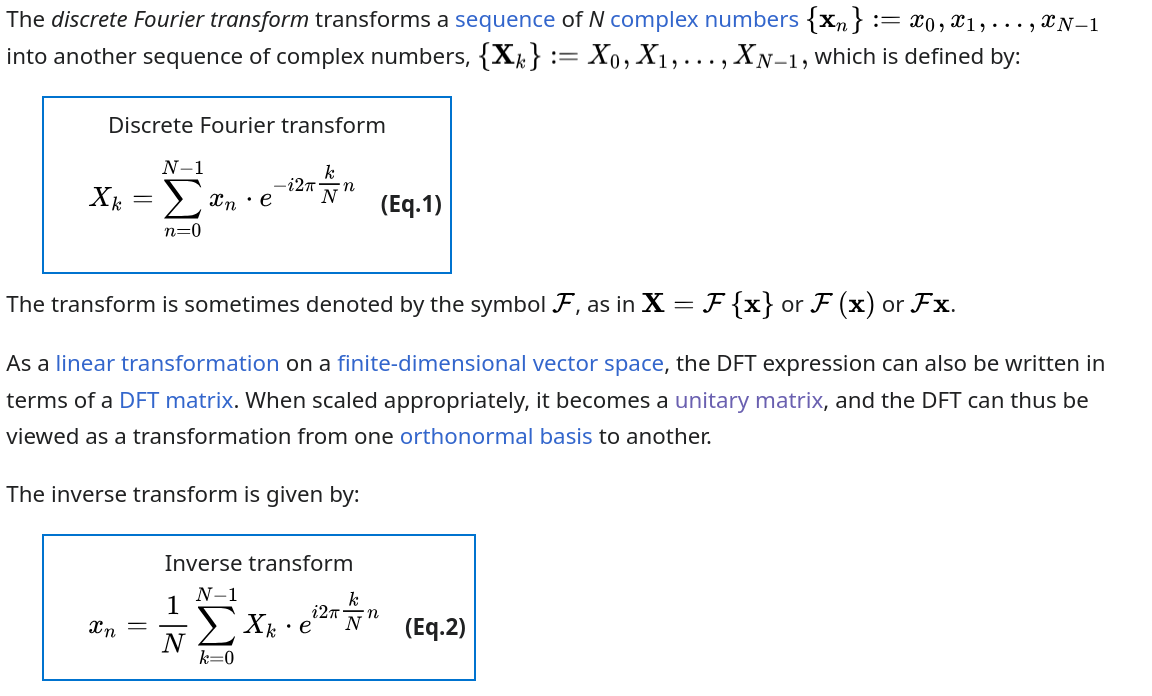

## Exponential form

The same periodic signal can be written with complex exponentials as

$$x(t) = \sum_{n=-\infty}^{\infty} c_n e^{j n\omega_0 t} \qquad \dots (6)$$

where the complex Fourier coefficients are

$$c_n = \frac{1}{T}\int_{t_0}^{t_0+T} x(t)\,e^{-j n\omega_0 t}\,dt. \qquad \dots (7)$$

Comparing (6) with the trigonometric series (1) gives the relation between the two sets of coefficients:

$$c_0 = a_0 = A_0,$$

$$c_n = \frac{a_n - j b_n}{2}, \qquad c_{-n} = \frac{a_n + j b_n}{2} = c_n^{*} \qquad (n \ge 1),$$

or, in the amplitude–phase notation,

$$a_n = 2\,\mathrm{Re}(c_n), \qquad b_n = -2\,\mathrm{Im}(c_n), \qquad A_n = 2|c_n|, \qquad \theta_n = \arg(c_n).$$

The power of the signal is distributed over the two-sided spectrum as

$$\frac{1}{T}\int_{t_0}^{t_0+T} |x(t)|^2\,dt = \sum_{n=-\infty}^{\infty} |c_n|^2.$$

## Discrete Fourier transform

Sampling the periodic signal at $t_n = n\Delta t$, $n = 0,\dots,N-1$, over one period $T = N\Delta t$ gives the finite sequence $x_n = x(t_n)$. Its discrete Fourier transform (DFT) is

$$X_k = \sum_{n=0}^{N-1} x_n\, e^{-j 2\pi k n / N}, \qquad k = 0,\dots,N-1 \qquad \dots (8)$$

and the original samples are recovered by the inverse DFT (IDFT)

$$x_n = \frac{1}{N}\sum_{k=0}^{N-1} X_k\, e^{j 2\pi k n / N}. \qquad \dots (9)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [30]:
def fourier_coefficients(f, T, N, n_int=20001):
    """Trigonometric Fourier coefficients of a T-periodic signal.

    The integrals are evaluated over one period [0, T] with the
    trapezoidal rule.

    Parameters
    ----------
    f : callable
        Periodic signal, evaluated on one period.
    T : float
        Period of the signal.
    N : int
        Number of harmonics (n = 1..N).
    n_int : int
        Number of integration nodes over one period.

    Returns
    -------
    a0 : float
        DC coefficient (1/T) * int f(t) dt.
    a : ndarray
        Cosine coefficients [a_1, ..., a_N].
    b : ndarray
        Sine coefficients [b_1, ..., b_N].
    """
    t = np.linspace(0.0, T, n_int)
    ft = f(t)
    w0 = 2.0 * np.pi / T

    # np.trapezoid(y, x) численно интегрирует по значениям функции y в точках х 
    # a_0 = \frac{1}{T}\int_{t_0}^{t_0+T} x(t)\,dt
    a0 = (1.0 / T) * np.trapezoid(ft, t)

    a = np.empty(N)
    b = np.empty(N)
    for n in range(1, N + 1):
        ## YOUR CODE HERE
        a[n - 1] = ...
        b[n - 1] = ...
    return a0, a, b

In [37]:
n_int = 20001
rmse = lambda x, y: np.sqrt(np.mean((x - y) ** 2))

f = lambda t: t ** 2
t = np.linspace(0.0, T, n_int)
a0, a, b = fourier_coefficients(f, T, N, n_int=n_int)
A, theta = amplitude_phase(a, b)

approx = fourier_series(t, a0, a, b, T, N)
assert rmse(f(t), approx) < 0.10

In [3]:
def amplitude_phase(a, b):
    """Amplitude and phase from the cosine/sine coefficients.

    A_n = sqrt(a_n^2 + b_n^2),  theta_n = -atan(b_n / a_n).

    arctan2 is used so that the phase lands in the correct quadrant.
    """
    A = np.hypot(a, b)
    theta = np.arctan2(-b, a)
    return A, theta

In [4]:
def fourier_series(t, a0, a, b, T, N):
    """Reconstruct x(t) = a0 + sum a_n cos(n w0 t) + b_n sin(n w0 t)."""
    w0 = 2.0 * np.pi / T
    x = np.full_like(t, a0, dtype=float)
    for n in range(1, N + 1):
        x += a[n - 1] * np.cos(n * w0 * t) + b[n - 1] * np.sin(n * w0 * t)
    return x


def fourier_series_amp_phase(t, A0, A, theta, T, N):
    """Reconstruct x(t) = A0 + sum A_n cos(n w0 t + theta_n)."""
    w0 = 2.0 * np.pi / T
    x = np.full_like(t, A0, dtype=float)
    for n in range(1, N + 1):
        x += A[n - 1] * np.cos(n * w0 * t + theta[n - 1])
    return x

In [5]:
def complex_coefficients(f, T, N, n_int=20001):
    """Complex exponential Fourier coefficients c_n, n = -N..N.

    c_n = (1/T) * int_0^T f(t) exp(-j n w0 t) dt,  w0 = 2 pi / T.
    """
    t = np.linspace(0.0, T, n_int)
    ft = f(t)
    w0 = 2.0 * np.pi / T

    n = np.arange(-N, N + 1)
    c = np.empty(2 * N + 1, dtype=complex)
    for i, k in enumerate(n):
        c[i] = (1.0 / T) * np.trapezoid(ft * np.exp(-1j * k * w0 * t), t)
    return n, c


def fourier_series_complex(t, n, c, T):
    """Reconstruct x(t) = sum_{n=-N..N} c_n exp(j n w0 t)."""
    w0 = 2.0 * np.pi / T
    x = np.zeros_like(t, dtype=complex)
    for k, ck in zip(n, c):
        x += ck * np.exp(1j * k * w0 * t)
    return x

In [6]:
def plot_fourier(f, T, N, n_points=2000, n_int=20001):
    """Signal, amplitude spectrum and phase spectrum of the N-harmonic series.

    Left panel: x(t) against the N-harmonic approximation.
    Middle panel: amplitude spectrum A_n.
    Right panel: phase spectrum theta_n.
    """
    t = np.linspace(0.0, T, n_points)
    a0, a, b = fourier_coefficients(f, T, N, n_int=n_int)
    A, theta = amplitude_phase(a, b)

    approx = fourier_series(t, a0, a, b, T, N)

    fig, (ax_f, ax_A,) = plt.subplots(1, 2, figsize=(16, 4.2))

    ax_f.plot(t, f(t), "k-", lw=2, label="$x(t)$")
    ax_f.plot(t, approx, "r--", lw=1.8, label=f"series, N={N}")
    ax_f.set_xlim(0.0, T)
    ax_f.set_xlabel("$t$")
    ax_f.set_ylabel("$x(t)$")
    ax_f.set_title("Trigonometric Fourier series")
    ax_f.legend()
    ax_f.grid(alpha=0.3)

    n = np.arange(1, N + 1)
    ax_A.stem(n, A, basefmt=" ")
    ax_A.set_xlabel("harmonic $n$")
    ax_A.set_ylabel("$A_n$")
    ax_A.set_title("Amplitude spectrum")
    ax_A.grid(alpha=0.3)

    fig.tight_layout()
    return fig, (ax_f, ax_A)

In [7]:
def plot_complex_spectrum(f, T, N, n_int=20001):
    """Two-sided magnitude and phase spectrum of the exponential series."""
    n, c = complex_coefficients(f, T, N, n_int=n_int)

    fig, (ax_m) = plt.subplots(1, 1, figsize=(12, 4.2))

    ax_m.stem(n, np.abs(c), basefmt=" ")
    ax_m.set_xlabel("harmonic $n$")
    ax_m.set_ylabel("$|c_n|$")
    ax_m.set_title("Two-sided magnitude spectrum")
    ax_m.grid(alpha=0.3)

    fig.tight_layout()
    return fig, (ax_m)

In [8]:
def dft(x):
    """Discrete Fourier transform (8): X_k = sum_n x_n exp(-j 2 pi k n / N)."""
    x = np.asarray(x, dtype=complex)
    N = x.size
    n = np.arange(N)
    k = n.reshape(-1, 1)
    W = np.exp(-2j * np.pi * k * n / N)
    return W @ x


def idft(X):
    """Inverse DFT (9): x_n = (1/N) sum_k X_k exp(j 2 pi k n / N)."""
    X = np.asarray(X, dtype=complex)
    N = X.size
    n = np.arange(N)
    k = n.reshape(-1, 1)
    W = np.exp(2j * np.pi * k * n / N)
    return (W @ X) / N

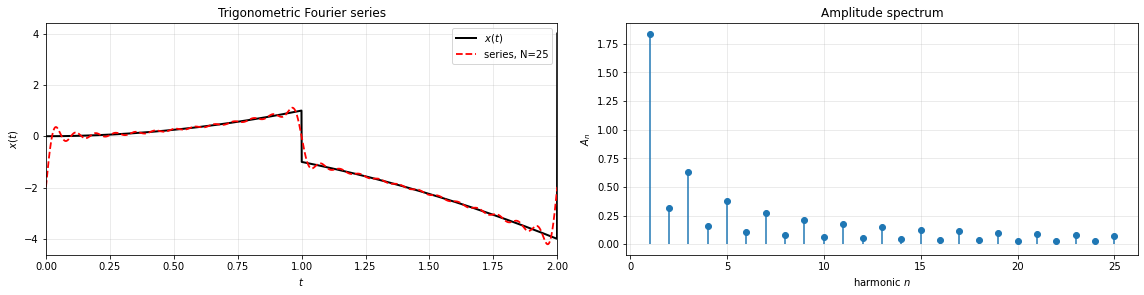

In [9]:
T = 2.0
# f = lambda t: np.where((t % T) < T / 2, 1.0, -1.0)
f = lambda t: t ** 2 * np.where((t % T) < T / 2, 1.0, -1.0)

fig, axes = plot_fourier(f, T, N=25)
plt.show()

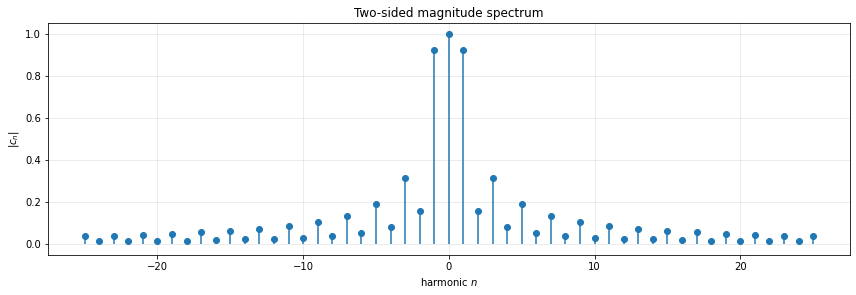

In [10]:
fig, axes = plot_complex_spectrum(f, T, N=25)
plt.show()

## Smoothness and the decay of the Fourier coefficients

$$|c_n| = O\!\left(\frac{1}{n^{p+1}}\right)$$
- **$p$ smooth derivatives:** $|c_n| = O(1/n^{p+1})$.


## Gibbs phenomenon


/tmp/ipykernel_131872/3680519710.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(fontsize=9)


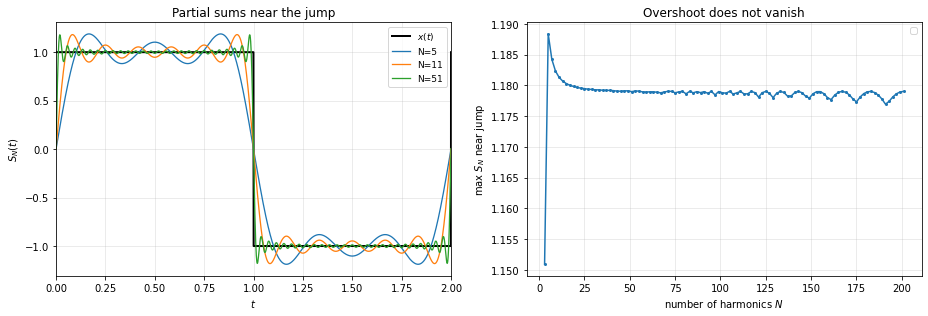

In [11]:
T = 2.0
square = lambda t: np.where((t % T) < T / 2, 1.0, -1.0)
t = np.linspace(0.0, T, 4001)

tt = np.linspace(0.0, np.pi, 200001)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(t, square(t), "k-", lw=2, label="$x(t)$")
for N in (5, 11, 51):
    a0, a, b = fourier_coefficients(square, T, N)
    ax1.plot(t, fourier_series(t, a0, a, b, T, N), lw=1.3, label=f"N={N}")
ax1.set_xlim(0.0, T)
ax1.set_xlabel("$t$")
ax1.set_ylabel("$S_N(t)$")
ax1.set_title("Partial sums near the jump")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

Ns = np.arange(3, 202, 2)
peaks = []
for N in Ns:
    a0, a, b = fourier_coefficients(square, T, N)
    S = fourier_series(t, a0, a, b, T, N)
    m = (t > 0.4 * T) & (t < 0.6 * T)
    peaks.append(S[m].max())

ax2.plot(Ns, peaks, ".-", ms=4)
# ax2.axhline(1.0 + overshoot, color="r", ls="--",
#             label=f"Gibbs")
ax2.set_xlabel("number of harmonics $N$")
ax2.set_ylabel("max $S_N$ near jump")
ax2.set_title("Overshoot does not vanish")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

fig.tight_layout()
plt.show()

## Удаление шума.

Для того чтобы удалить шум, мы предполагаем, что исходный сигнал, который мы хотим восстановить хорошо аппроксимируется 
низкочастотными колебаниями, а шум больше сосредоточен на высоких, поэтому, когда мы раскладываем сигнал в тригонометрический ряд, 
то нам нужно выбрать N - сколько первых гармоник мы оставляем

$$S_N(t) = a_0 + \sum_{n=1}^{N} a_n\cos(n\omega_0 t) + b_n\sin(n\omega_0 t).$$


RMSE noisy    : 0.5868
RMSE denoised : 0.0589


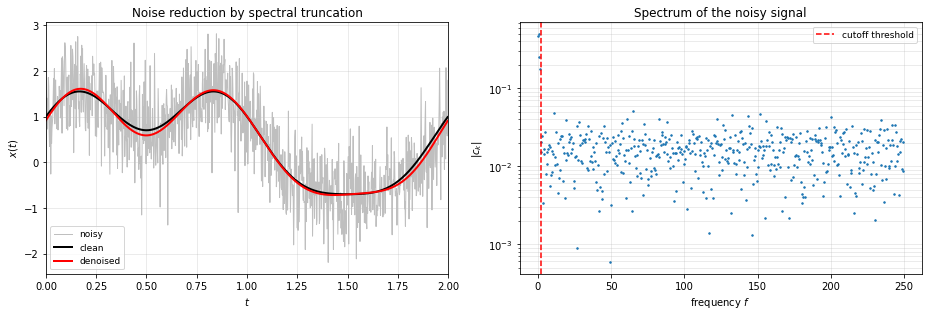

In [12]:
rng = np.random.default_rng(0)
T = 2.0
N_samp = 1000
t = np.linspace(0.0, T, N_samp, endpoint=False)


def clean(t):
    return (0.5 + np.sin(2.0 * np.pi * t / T)
            + 0.5 * np.cos(4.0 * np.pi * t / T)
            + 0.3 * np.sin(6.0 * np.pi * t / T))


xt = clean(t)
yt = xt + 0.6 * rng.standard_normal(N_samp)

threshold = 2.0
freq = np.fft.fftfreq(N_samp, d=T / N_samp)
Y = np.fft.fft(yt)
Yf = np.where(np.abs(freq) <= threshold, Y, 0.0)
y_den = np.real(np.fft.ifft(Yf))

rmse = lambda a, b: np.sqrt(np.mean((a - b) ** 2))
print(f"RMSE noisy    : {rmse(yt, xt):.4f}")
print(f"RMSE denoised : {rmse(y_den, xt):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

ax1.plot(t, yt, color="0.75", lw=1, label="noisy")
ax1.plot(t, xt, "k-", lw=2, label="clean")
ax1.plot(t, y_den, "r-", lw=2, label=f"denoised")
ax1.set_xlim(0.0, T)
ax1.set_xlabel("$t$")
ax1.set_ylabel("$x(t)$")
ax1.set_title("Noise reduction by spectral truncation")
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

half = N_samp // 2
ax2.semilogy(freq[:half], np.abs(Y[:half]) / N_samp, ".", ms=3)
ax2.axvline(threshold, color="r", ls="--", label=f"cutoff threshold")
ax2.set_xlabel("frequency $f$")
ax2.set_ylabel("$|c_k|$")
ax2.set_title("Spectrum of the noisy signal")
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3, which="both")

fig.tight_layout()
plt.show()

In [13]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


def animate_fourier(f, T, N_max=25, n_points=2000, n_int=20001, interval=250):
    """Animate the series as the number of harmonics N grows.

    Left panel: x(t) and the current N-term approximation.
    Right panel: amplitude spectrum A_n for n = 1..N.
    """
    t = np.linspace(0.0, T, n_points)
    a0, a, b = fourier_coefficients(f, T, N_max, n_int=n_int)
    A, theta = amplitude_phase(a, b)
    xt = f(t)

    fig, (ax_f, ax_A) = plt.subplots(1, 2, figsize=(12, 4.5))
    ax_f.plot(t, xt, "k-", lw=2, label="$x(t)$")
    (line,) = ax_f.plot([], [], "r--", lw=1.8)
    ax_f.set_xlim(0.0, T)
    ax_f.set_xlabel("$t$")
    ax_f.set_ylabel("$x(t)$")
    ax_f.legend(loc="upper right")
    ax_f.grid(alpha=0.3)

    ax_A.set_xlim(0.5, N_max + 0.5)
    ax_A.set_ylim(0.0, 1.1 * A.max())
    ax_A.set_xlabel("harmonic $n$")
    ax_A.set_ylabel("$A_n$")
    ax_A.grid(alpha=0.3)

    stem_container = None

    def update(N):
        nonlocal stem_container
        approx = fourier_series(t, a0, a, b, T, N)
        line.set_data(t, approx)
        ax_f.set_title(f"Fourier series, N={N}")
        if stem_container is not None:
            stem_container.remove()
        stem_container = ax_A.stem(np.arange(1, N + 1), A[:N], basefmt=" ")
        ax_A.set_title(f"Amplitude spectrum, N={N}")
        return (line,)

    anim = FuncAnimation(fig, update, frames=range(1, N_max + 1),
                         interval=interval, repeat=False)
    fig.tight_layout()
    return anim

In [14]:
anim = animate_fourier(f, T, N_max=75)
html = anim.to_jshtml()
plt.close(anim._fig)
HTML(html)